# Augmented Synthetic Difference-in-Differences (ASDID)

ASDID is a causal inference estimator for panel data that combines the strengths of
Difference-in-Differences (DID) and Synthetic Control (SC) methods, building on the
Synthetic Difference-in-Differences (SDID) framework by Arkhangelsky et al. (2021).

### When to use ASDID

- You have panel data (units observed over time) with a treatment that starts at a known time
- Parallel trends may not hold exactly (some units are better controls than others)
- You have many control units (100s to millions) and want to select the best donors
- You need power analysis or inference via placebo tests

### Key differences from SDID

| Feature | SDID | ASDID |
|---------|------|-------|
| Fixed effects | Intercept in solver | Two-way demeaning (explicit FE removal) |
| Regularization | `eta * noise_level` (hand-tuned) | MAD² of first-differences (data-driven, robust) |
| Time weighting | Equal weight per observation | Inverse-variance weighting (downweights noisy periods) |
| Scalability | ~1000 units (Frank-Wolfe) | 5M+ units (PGD + donor screening) |
| Covariates | Joint optimization | Partial-out via FWL theorem |



## Quick Start: Panel Estimator

The simplest way to use ASDID within the azcausal framework:

In [1]:
from azcausal.data import CaliforniaProp99
from azcausal.estimators.panel.asdid import ASDID

# Load the California Proposition 99 dataset
panel = CaliforniaProp99().panel()

# Fit ASDID
result = ASDID().fit(panel)
print(result.summary())

╭──────────────────────────────────────────────────────────────────────────────╮
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect: -14.60                                                              |
|  Observed: 60.35                                                             |
|  Counter Factual: 74.95                                                      |
├──────────────────────────────────────────────────────────────────────────────┤
|                                  Percentage                                  |
|  Effect: -19.48                                                              |
|  Observed: 80.52          

## Standalone Package

The standalone module has **no dependencies on azcausal** — only numpy and scipy.
It can be copied into any project and used independently.

```python
from azcausal.standalone.asdid import asdid, did, se_placebo, power_curve
```

### Data Preparation

Convert a long-format DataFrame to the matrix inputs using `df_to_matrix`. It validates that treatment assignment is consistent (block treatment).

In [2]:
from azcausal.standalone.asdid import df_to_matrix, asdid
from azcausal.data import CaliforniaProp99

# Get raw DataFrame
df = CaliforniaProp99().df()
print(df.head())

# Convert to matrix format
Y, n_pre, treat = df_to_matrix(df, time_col="Year", unit_col="State",
                               outcome_col="PacksPerCapita", treat_col="treated")
print(f"Y: {Y.shape}, n_pre: {n_pre}, n_treat: {treat.sum()}")

# Run ASDID directly
att, lambd, omega, donors = asdid(Y, n_pre, treat)
print(f"ATT: {att[0]:.2f}")

         State  Year  PacksPerCapita  treated
0      Alabama  1970       89.800003        0
1     Arkansas  1970      100.300003        0
2     Colorado  1970      124.800003        0
3  Connecticut  1970      120.000000        0
4     Delaware  1970      155.000000        0
Y: (31, 39), n_pre: 19, n_treat: 1
ATT: -14.60


### Estimation

Both `asdid()` and `did()` return `(att, lambd, omega, donors)`:

In [3]:
import numpy as np
from azcausal.standalone.asdid import asdid, did

# Prepare data as numpy arrays
panel = CaliforniaProp99().panel()
Y = panel['PacksPerCapita'].values  # (n_time, n_units)
n_pre = 19  # 19 pre-treatment periods
treat = np.zeros(39, dtype=bool)
treat[2] = True  # California is the treated unit

# ASDID: learns optimal unit weights (omega) and time weights (lambda)
att, lambd, omega, donors = asdid(Y, n_pre, treat)
print(f'ASDID: ATT = {att[0]:.2f} packs per capita')

# DID: uniform weights (standard difference-in-differences)
att_d, lambd_d, omega_d, donors_d = did(Y, n_pre, treat)
print(f'DID:   ATT = {att_d[0]:.2f} packs per capita')

ASDID: ATT = -14.60 packs per capita
DID:   ATT = -27.35 packs per capita


### Inference

Standard errors can be computed via:
- **Placebo** (`se_placebo`): Permutation-based, recommended for n_treat=1. Correct coverage.
- **Jackknife** (`se_jackknife`): Analytical leave-one-out, fast. Requires n_treat ≥ 2.

Inference functions take an **estimator object** as the first argument, decoupling estimation from inference:

In [4]:
from azcausal.standalone.asdid import ASDID as ASDIDEstimator, se_placebo, summary

# Create estimator object (holds configuration)
est = ASDIDEstimator(max_donors=10000)

# Placebo SE: permutes treatment assignment to estimate null distribution
se = se_placebo(est, Y, n_pre, treat, n_placebo=200)

# Print formatted summary with confidence intervals
res = asdid(Y, n_pre, treat, return_dict=True)
summary(Y, n_pre, treat, res, se=se, conf=90, title='California Prop 99')

╭──────────────────────────────────────────────────────────────────────────────╮
│                              California Prop 99                              │
├══════════════════════════════════════════════════════════════════════════════┤
│                                    Panel                                     │
│  Time Periods: 31 (19/12) total (pre/post)                                   │
│  Units: 39 (38/1) total (contr/treat)                                        │
│  Donors: 38                                                                  │
├──────────────────────────────────────────────────────────────────────────────┤
│                                     ATT                                      │
│  Effect (±SE): -14.60 (±9.1203)                                              │
│  Confidence Interval (90%): [-29.60 , 0.40]                                  │
│  Observed: 60.35                                                             │
│  Counter Factual: 74.95   

### Power Analysis

Simulate experiments to determine statistical power at different effect sizes.
Uses the control panel to generate random treatment assignments and inject known ATTs.

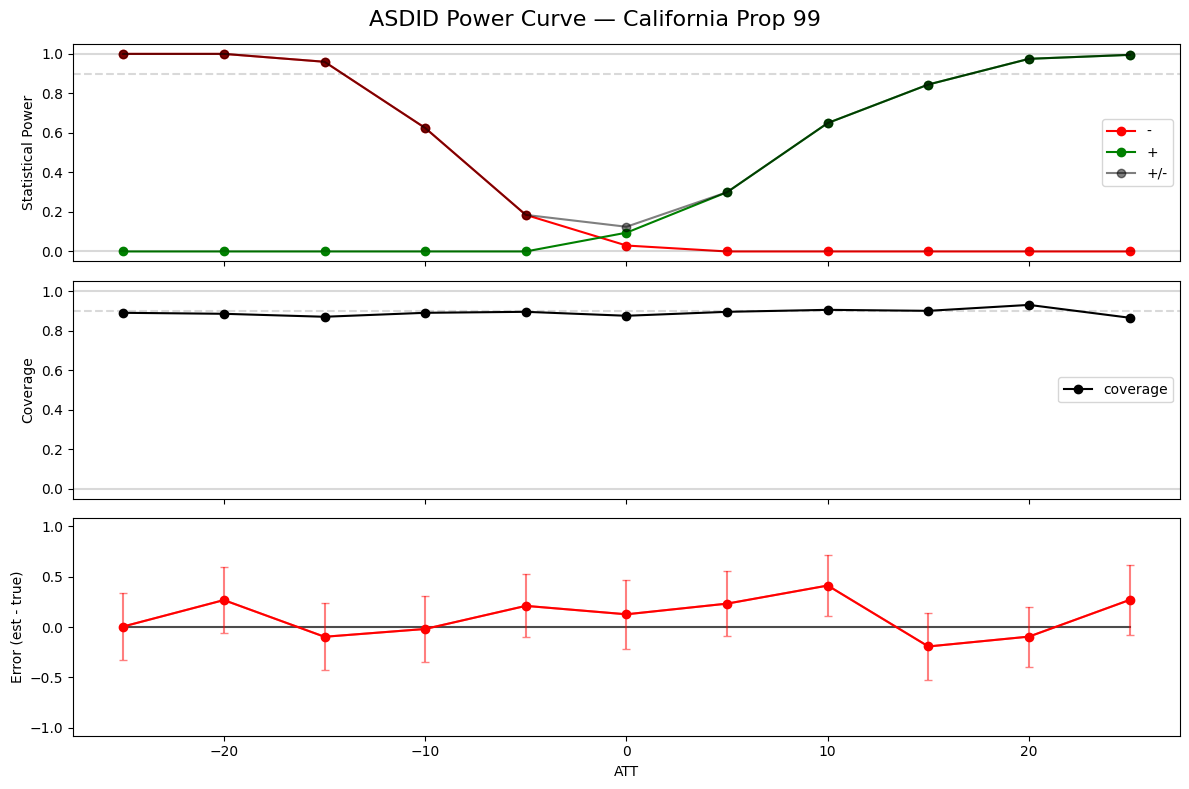

ASDID MDE (90% conf, 90% power): 26.7 packs


In [5]:
from azcausal.standalone.asdid import power_curve, plot_power_curve, mde, DID
import matplotlib.pyplot as plt

# Compare power: ASDID vs DID
att_values = [-25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25]

df_asdid = power_curve(est, Y, n_pre, n_treat=5, att_values=att_values, n_samples=200)
fig, _ = plot_power_curve(df_asdid, title='ASDID Power Curve — California Prop 99')
plt.show()

# Minimum detectable effect
print(f'ASDID MDE (90% conf, 90% power): {mde(se, conf=90, power=0.9):.1f} packs')

### Visualization

Three-panel plot showing raw data, demeaned residuals, and the synthetic control fit:

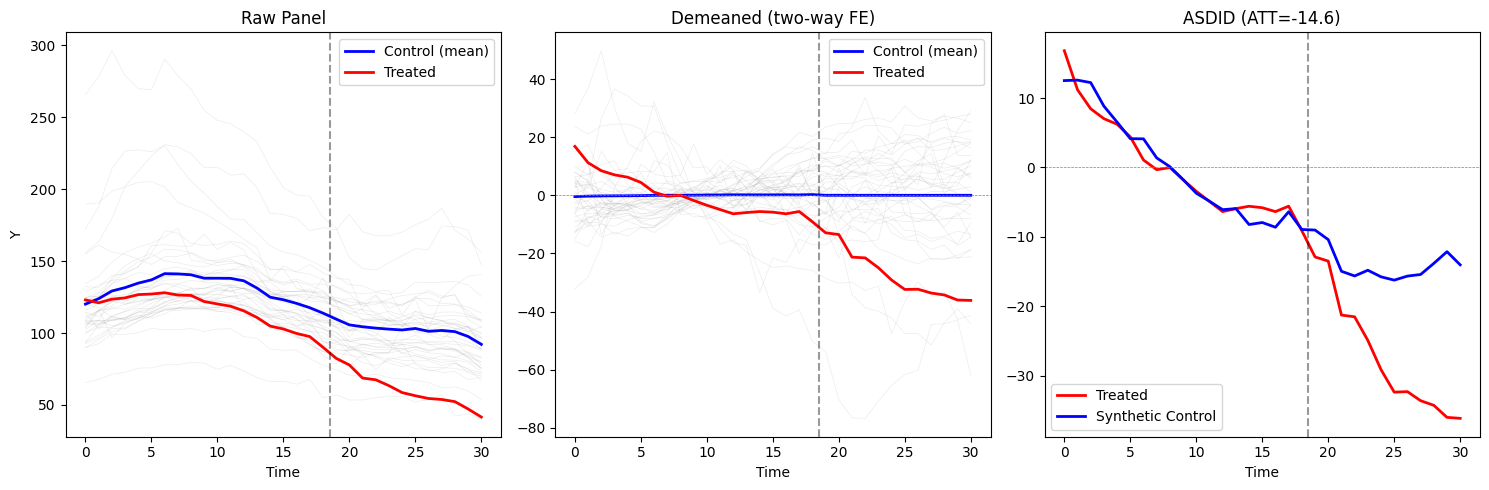

In [6]:
from azcausal.standalone.asdid import plot_asdid

res = asdid(Y, n_pre, treat, return_dict=True)
fig, _ = plot_asdid(Y, res)
plt.show()

### Scalability

ASDID scales to millions of units via donor screening: an unconstrained ridge
pre-screen identifies the top-K most relevant control units, then PGD optimizes
weights on the reduced set.

In [7]:
import time

# Generate a large panel: 500k units, 13 time periods
np.random.seed(42)
Y_big = np.random.randn(13, 500_000).astype(np.float32) * 0.5
Y_big[9:, -100:] += 3.0
treat_big = np.zeros(500_000, dtype=bool)
treat_big[-100:] = True

t0 = time.time()
att, lambd, omega, donors = asdid(Y_big, 9, treat_big, max_donors=1000)
elapsed = time.time() - t0

print(f'Panel: 500,000 units × 13 time periods')
print(f'ATT: {att[0]:.2f} (true: 3.0)')
print(f'Selected {len(donors)} donors from 499,900 controls')
print(f'Time: {elapsed:.2f}s')

Panel: 500,000 units × 13 time periods
ATT: 3.01 (true: 3.0)
Selected 1000 donors from 499,900 controls
Time: 0.10s


### Covariate Adjustment

ASDID supports time-varying covariates via the Frisch-Waugh-Lovell theorem.
Covariates are partialled out before weight estimation, removing confounding
from observed factors that shift differently for treated and control units.

In [8]:
# Example: covariates that confound the treatment effect
np.random.seed(42)
n_time, n_units, n_cov = 50, 30, 2
n_pre, n_treat = 35, 5
true_att, true_beta = 3.0, np.array([4.0, -2.5])

treat_ex = np.zeros(n_units, dtype=bool); treat_ex[-n_treat:] = True
X = np.random.randn(n_time, n_units, n_cov) * 0.5
X[n_pre:, -n_treat:, 0] += 1.5  # confounding covariate shift

Y_ex = np.random.randn(n_time, n_units) * 0.3
Y_ex += np.einsum('tnc,c->tn', X, true_beta)  # covariate effect
Y_ex[n_pre:, -n_treat:] += true_att

# Without covariates: biased
att_no_x, _, _, _ = asdid(Y_ex, n_pre, treat_ex)
# With covariates: corrected
att_with_x, _, _, _ = asdid(Y_ex, n_pre, treat_ex, X=X)

print(f'True ATT: {true_att}')
print(f'Without X: {att_no_x[0]:.2f} (biased by confounding)')
print(f'With X:    {att_with_x[0]:.2f} (corrected)')

True ATT: 3.0
Without X: 9.05 (biased by confounding)
With X:    3.10 (corrected)
